#Experiment 11: Compare RNN, LSTM, and GRU for Sentiment Analysis

Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

Step 2: Load Dataset

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 3: Padding

In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

Step 4: Function to Create Models

In [4]:
def build_model(rnn_type):
    model = Sequential()

    model.add(Embedding(vocab_size, 128, input_length=max_len))

    if rnn_type == "RNN":
        model.add(SimpleRNN(64))
    elif rnn_type == "LSTM":
        model.add(LSTM(64))
    elif rnn_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

Step 5: Train All Models

In [5]:
history_dict = {}
results = {}

for rnn_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {rnn_type} model...\n")

    model = build_model(rnn_type)

    history = model.fit(X_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_data=(X_test, y_test),
                        verbose=1)

    loss, acc = model.evaluate(X_test, y_test)

    history_dict[rnn_type] = history
    results[rnn_type] = acc


Training RNN model...

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 118ms/step - accuracy: 0.6879 - loss: 0.5721 - val_accuracy: 0.8050 - val_loss: 0.4417
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.8587 - loss: 0.3332 - val_accuracy: 0.7643 - val_loss: 0.5033
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.8459 - loss: 0.3454 - val_accuracy: 0.7475 - val_loss: 0.5917
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7475 - loss: 0.5917

Training LSTM model...

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 145s 365ms/step - accuracy: 0.7881 - loss: 0.4585 - val_accuracy: 0.8496 - val_loss: 0.3606
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 361ms/step - accuracy: 0.8969 - loss: 0.2604 - val_accuracy: 0.8713 - val_loss: 0.3153
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 130s 332ms/step - accuracy: 0.9286 - loss: 0.1887 - val_accuracy: 0.8669 - val_loss: 0.3362
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8669 - loss: 0.3362

Training GRU model...

Epoch 1/3
391/391 ━━━━━━

Step 6: Compare Accuracy

In [6]:
for model_name, acc in results.items():
    print(f"{model_name} Accuracy: {acc:.4f}")

RNN Accuracy: 0.7475
LSTM Accuracy: 0.8669
GRU Accuracy: 0.8786


Step 7: Plot Comparison

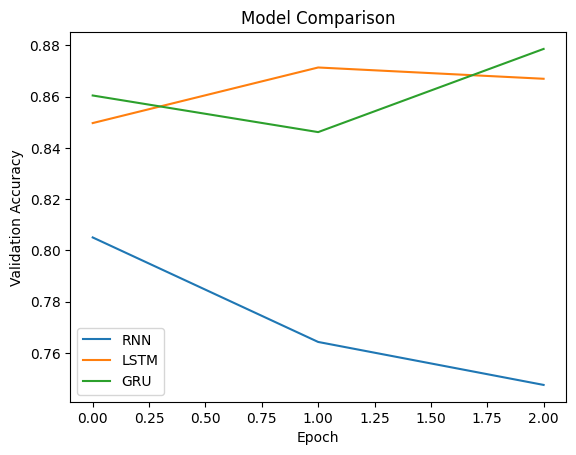

In [7]:
for rnn_type in history_dict:
    plt.plot(history_dict[rnn_type].history['val_accuracy'], label=rnn_type)

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()